Yair Franco, 2026

Using OpenQuake and Distances class to create GMM ShakeMaps

In [8]:
import time
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

from matplotlib.colors import LinearSegmentedColormap

from openquake.hazardlib.contexts import RuptureContext
from openquake.hazardlib.contexts import DistancesContext
from openquake.hazardlib.contexts import SitesContext
from openquake.hazardlib import imt, const

from openquake.hazardlib.gsim.abrahamson_2014 import AbrahamsonEtAl2014
from openquake.hazardlib.gsim.boore_2014 import BooreEtAl2014
from openquake.hazardlib.gsim.campbell_bozorgnia_2014 import CampbellBozorgnia2014
from openquake.hazardlib.gsim.chiou_youngs_2014 import ChiouYoungs2014

from distance_helpers import Distances, gen_surface_grid

import warnings
warnings.filterwarnings("ignore", category=DeprecationWarning)
warnings.filterwarnings("ignore", category=FutureWarning)

In [9]:
def rake2mech(rake):
    # helper for formatting plot titles
    if 45 < rake < 135:
        return "thrust"
    elif -135 < rake < -45:
        return "normal"
    else:
        return "strike-slip"

In [10]:
colors = ['white','cyan','lightblue','blue','green','yellow','orange','darkorange','red','darkred']
ns = np.array([0,0.02,0.1,1.4,4.7,9.6,20,41,86,178])
MMI_ticks = ['I','II','III','IV','V','VI','VII','VIII','IX','X']
nodes = (ns - np.min(ns)) / (np.max(ns) - np.min(ns))

MMI_cmap = LinearSegmentedColormap.from_list("MMI_cmap", list(zip(nodes,colors)))

In [11]:
start = time.time()
gridx, gridy = 100,100
resx, resy = 100,100
p = gen_surface_grid(gridx,gridy,resx,resy)

#some parameters that are more convenient as variables
strike = 0
dip = 60
fw = 15.0
fl = 30.0
hdep = 10.5
ztor = 0.0

rctx = RuptureContext()
rctx.mag = 7.1
rctx.strike = strike
rctx.dip = dip
rctx.rake = -90
rctx.ztor = ztor
rctx.hypo_depth = hdep
rctx.width = fw

dctx = DistancesContext()

"""DISTANCE CALCULATIONS"""

"""BAKER FUNCTION CALCUALTIONS"""
d = Distances(
    dip = dip,
    strike = strike,
    fault_length=fl,
    fault_width=fw,
    hyp_depth=hdep,
    hyp_along_strike=15,
    ztor=ztor
)
rjbs = d.calc_Rjb(p)
rrups = d.calc_Rrup(p)
rxs = d.calc_Rx(p)

"""DISTANCE CALCULATIONS END"""

# assign to openquake context
dctx.rrup = rrups
dctx.rjb = rjbs
dctx.rx = rxs
dctx.ry0 = None #TODO: if I really need this, I can add a calculation for this to the distances module

n = len(p)
sitecol_dict = {
    'sids': np.arange(1, n + 1),
    'vs30': 760.0 + np.zeros(n, dtype=float),
    'vs30measured': np.zeros(n, dtype=bool),
    'z1pt0': 50.0 + np.zeros(n, dtype=float),
    'z2pt5': np.nan + np.zeros(n, dtype=float),
    }
sitecollection = pd.DataFrame(sitecol_dict)
sctx = SitesContext(sitecol=sitecollection)

IMT = imt.PGV()
uncertaintytype = const.StdDev.TOTAL

ASK14 = AbrahamsonEtAl2014()
BSSA14 = BooreEtAl2014()
CB14 = CampbellBozorgnia2014()
CY14 = ChiouYoungs2014()

# calculate ln ground motions for each
ln_median_ask14, ln_sd_ask14 = ASK14.get_mean_and_stddevs(sctx, rctx, dctx, IMT, [uncertaintytype])
ln_median_bssa14, ln_sd_bssa14 = BSSA14.get_mean_and_stddevs(sctx, rctx, dctx, IMT, [uncertaintytype])
ln_median_cb14, ln_sd_cb14 = CB14.get_mean_and_stddevs(sctx, rctx, dctx, IMT, [uncertaintytype])
ln_median_cy14, ln_sd_cy14 = CY14.get_mean_and_stddevs(sctx, rctx, dctx, IMT, [uncertaintytype])

ln_median_ac14 = 0.25 * (ln_median_ask14 + ln_median_bssa14 + ln_median_cb14 + ln_median_cy14)
ln_sd_ac14 = 0.25 * (ln_sd_ask14[0] + ln_sd_bssa14[0] + ln_sd_cb14[0] + ln_sd_cy14[0]) # sds are in a list of length 1

end = time.time()
print(f'Cell execution time: {end-start} s')

Cell execution time: 0.018615007400512695 s


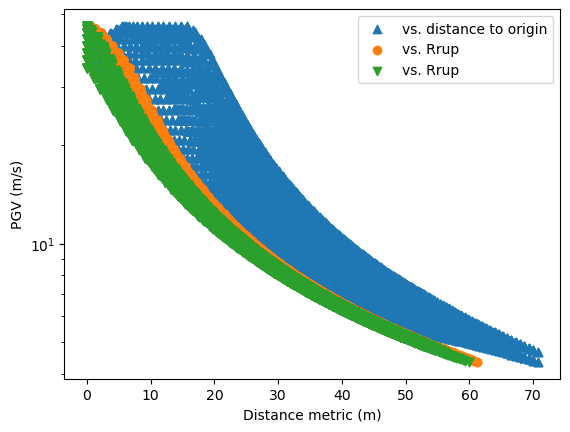

In [12]:
ask = np.exp(ln_median_ask14)
ac = np.exp(ln_median_ac14)
plt.scatter(np.linalg.norm(p,axis=1),ac,marker='^',label='vs. distance to origin')
plt.scatter(rrups,ac,marker='o',label='vs. Rrup')
plt.scatter(rjbs,ac,marker='v',label='vs. Rrup')
plt.xlabel("Distance metric (m)")
plt.ylabel("PGV (m/s)")
plt.yscale("log")
plt.legend();

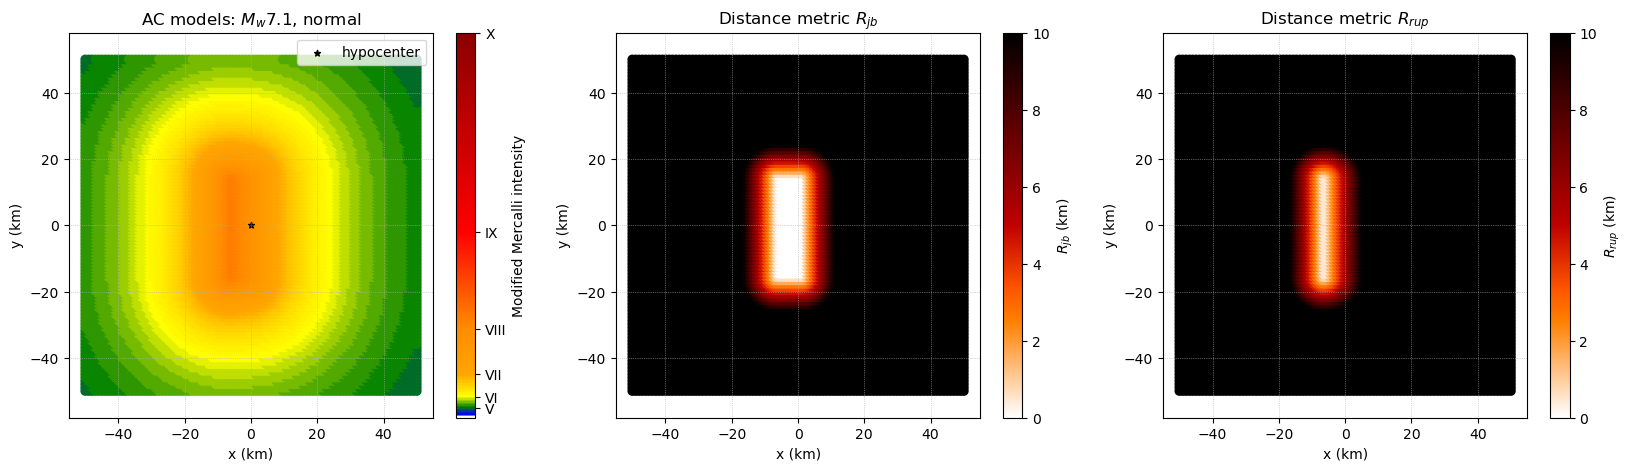

In [13]:
fig, axi = plt.subplots(1,3,figsize=[20,5])

x,y = p[:,0], p[:,1]

sc1 = axi[0].scatter(x,y,c=ac,cmap=MMI_cmap)
axi[0].scatter(0,0,s=20,marker='*',c='k',label='hypocenter')
sc1.set_clim(min(ns),max(ns))
cb_MMI = fig.colorbar(label='Modified Mercalli intensity',mappable=sc1)
cb_MMI.set_ticks(ns[4:])
cb_MMI.set_ticklabels(MMI_ticks[4:])
axi[0].set(**{
    'title': f'AC models: $M_w${rctx.mag}, {rake2mech(rctx.rake)}',
    'xlabel': 'x (km)',
    'ylabel': 'y (km)',
})
axi[0].legend()

sc2 = axi[1].scatter(x,y,c=rjbs,cmap='gist_heat_r')
fig.colorbar(label=r'$R_{jb}$ (km)',mappable=sc2)
sc2.set_clim(0,10)

axi[1].set(**{
    'title': 'Distance metric $R_{jb}$',
    'xlabel': 'x (km)',
    'ylabel': 'y (km)',
});

sc3 = axi[2].scatter(x,y,c=rrups,cmap='gist_heat_r')
fig.colorbar(label=r'$R_{rup}$ (km)',mappable=sc3)
sc3.set_clim(0,10)

axi[2].set(**{
    'title': 'Distance metric $R_{rup}$',
    'xlabel': 'x (km)',
    'ylabel': 'y (km)',
});

[ax.axis('equal') for ax in axi]
[ax.grid(ls=':',lw=0.5) for ax in axi];

Perhaps a better way to plot than using plt.scatter()?

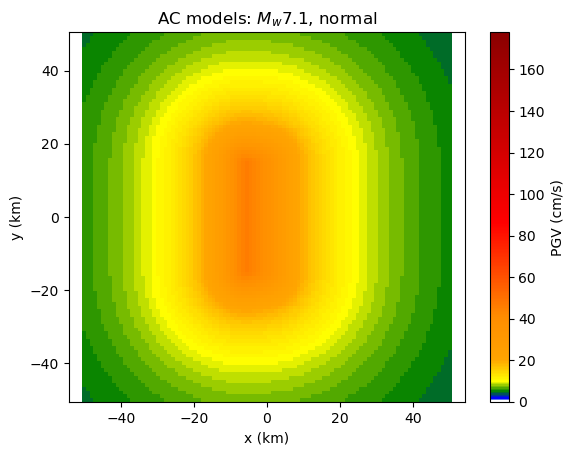

In [14]:
x_grid = np.linspace(-gridx / 2, gridx / 2, resx)
y_grid = np.linspace(-gridy / 2, gridy / 2, resy)
X, Y = np.meshgrid(x_grid, y_grid)

ac_resh = np.reshape(ac,(resx,resy))
plt.pcolormesh(X,Y,ac_resh,cmap=MMI_cmap)
plt.clim(min(ns),max(ns))
plt.colorbar(label='PGV (cm/s)')
plt.title(f"AC models: $M_w${rctx.mag}, {rake2mech(rctx.rake)}")
plt.xlabel('x (km)')
plt.ylabel('y (km)')
plt.axis('equal')
plt.show()